## Naive Bayes Regresión

In [1]:
!pip install pyreadr

Defaulting to user installation because normal site-packages is not writeable


In [16]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pyreadr

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, classification_report


In [3]:
# Cargar archivo .RData
resultado = pyreadr.read_r("data/listings.RData")
df = resultado["listings"]

df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [4]:
df.shape

(171748, 80)

In [5]:
df.columns.tolist()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [6]:
# Limpiar variable respuesta
df["price"] = pd.to_numeric(
    df["price"].astype(str).str.replace(r"[$,]", "", regex=True),
    errors="coerce"
)

# Convertir columnas que parecen numéricas pero vienen como texto
for col in ["host_response_rate", "host_acceptance_rate", "host_listings_count", 
            "host_total_listings_count", "bedrooms"]:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace("%", "", regex=False),
            errors="coerce"
        )

df["price"].describe()

count    76246.000000
mean       750.509220
std       4250.606945
min          8.000000
25%        120.000000
50%        193.000000
75%        326.000000
max      50123.000000
Name: price, dtype: float64

In [7]:
# Selección de variables 
columnas_numericas = [
    "latitude", "longitude", "accommodates", "bathrooms", "bedrooms", "beds",
    "minimum_nights", "maximum_nights", "minimum_nights_avg_ntm", "maximum_nights_avg_ntm",
    "availability_30", "availability_60", "availability_90", "availability_365",
    "number_of_reviews", "number_of_reviews_ltm", "number_of_reviews_l30d",
    "availability_eoy", "number_of_reviews_ly", "estimated_occupancy_l365d",
    "review_scores_rating", "review_scores_accuracy", "review_scores_cleanliness",
    "review_scores_checkin", "review_scores_communication", "review_scores_location",
    "review_scores_value", "calculated_host_listings_count",
    "calculated_host_listings_count_entire_homes",
    "calculated_host_listings_count_private_rooms",
    "calculated_host_listings_count_shared_rooms", "reviews_per_month",
    "host_response_rate", "host_acceptance_rate", "host_listings_count",
    "host_total_listings_count"
]

columnas_categoricas = [
    "host_response_time", "host_is_superhost", "host_has_profile_pic",
    "host_identity_verified", "neighbourhood_group_cleansed", "room_type",
    "has_availability", "instant_bookable", "city"
]

columnas_usar = [c for c in columnas_numericas + columnas_categoricas + ["price"] if c in df.columns]

data = df[columnas_usar].copy()
data = data[data["price"].notna()].copy()

data.shape

(76246, 46)

In [8]:
TARGET = "price"

X = data.drop(columns=[TARGET]).copy()
y = data[TARGET].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (60996, 45)
X_test: (15250, 45)
y_train: (60996,)
y_test: (15250,)


In [9]:
# One-hot encoding para variables categóricas
X_train_proc = pd.get_dummies(X_train, dummy_na=True)
X_test_proc = pd.get_dummies(X_test, dummy_na=True)

# Alinear columnas entre train y test
X_train_proc, X_test_proc = X_train_proc.align(
    X_test_proc,
    join="left",
    axis=1,
    fill_value=0
)

# Imputación
imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train_proc)
X_test_imp = imputer.transform(X_test_proc)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imp)
X_test_scaled = scaler.transform(X_test_imp)

print("Datos listos para el modelo")
print("Train procesado:", X_train_scaled.shape)
print("Test procesado:", X_test_scaled.shape)

Datos listos para el modelo
Train procesado: (60996, 119)
Test procesado: (15250, 119)


In [10]:
n_bins = 10

y_train_bins, bin_edges = pd.qcut(
    y_train,
    q=n_bins,
    labels=False,
    retbins=True,
    duplicates="drop"
)

y_train_bins = pd.Series(y_train_bins, index=y_train.index).astype(int)

bin_summary = pd.DataFrame({
    "price": y_train,
    "bin": y_train_bins
})

bin_means = bin_summary.groupby("bin")["price"].mean().sort_index()

nb_reg = GaussianNB()
nb_reg.fit(X_train_scaled, y_train_bins)

print("Modelo entrenado")
print("Clases usadas:", list(nb_reg.classes_))

Modelo entrenado
Clases usadas: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


In [11]:
def predecir_valor_continuo(modelo, X_scaled, valores_por_bin):
    proba = modelo.predict_proba(X_scaled)
    clases = modelo.classes_
    valores = valores_por_bin.reindex(clases).values
    pred = (proba * valores).sum(axis=1)
    return pred

y_pred_train = predecir_valor_continuo(nb_reg, X_train_scaled, bin_means)
y_pred_test = predecir_valor_continuo(nb_reg, X_test_scaled, bin_means)

print("Primeras predicciones en test:")
print(np.round(y_pred_test[:10], 2))

Primeras predicciones en test:
[ 94.48 119.08  89.81  74.83 330.15  94.5  119.99  92.72  71.17  57.57]


In [12]:
def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    return pd.Series({
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE (%)": mape
    })

metricas_train = regression_metrics(y_train, y_pred_train)
metricas_test = regression_metrics(y_test, y_pred_test)

metricas_df = pd.DataFrame({
    "Entrenamiento": metricas_train,
    "Prueba": metricas_test
})

metricas_df

,Entrenamiento,Prueba
MAE,636.249147,664.504398
RMSE,4262.746634,4347.221678
R2,-0.013619,-0.014460
MAPE (%),49.545263,51.229944


In [13]:
resultados_test = pd.DataFrame({
    "Real": y_test.values,
    "Predicho": np.round(y_pred_test, 2),
    "Error": np.round(y_test.values - y_pred_test, 2),
    "Error absoluto": np.round(np.abs(y_test.values - y_pred_test), 2)
}, index=y_test.index)

resultados_test.head(15)

,Real,Predicho,Error,Error absoluto
21455,194.0,94.48,99.52,99.52
44207,300.0,119.08,180.92,180.92
163610,89.0,89.81,-0.81,0.81
145688,51.0,74.83,-23.83,23.83
19036,198.0,330.15,-132.15,132.15
21468,287.0,94.50,192.50,192.50
25230,177.0,119.99,57.01,57.01
18187,171.0,92.72,78.28,78.28
157967,54.0,71.17,-17.17,17.17
48161,72.0,57.57,14.43,14.43


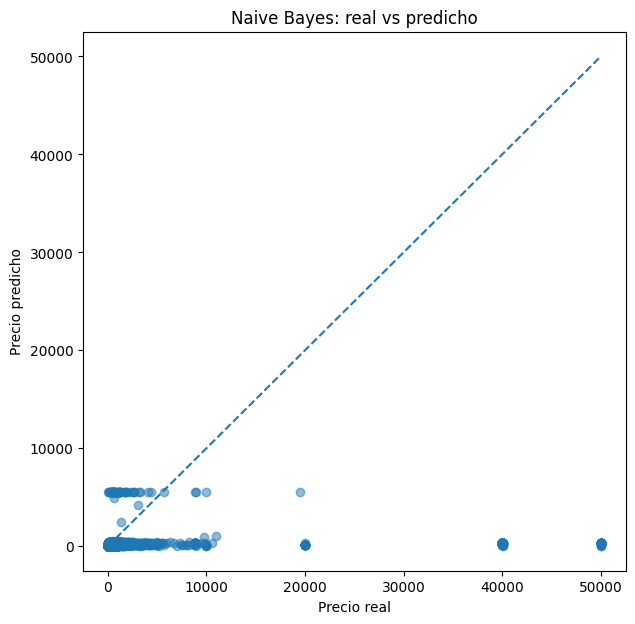

In [14]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred_test, alpha=0.5)
lim_inf = min(y_test.min(), y_pred_test.min())
lim_sup = max(y_test.max(), y_pred_test.max())

plt.plot([lim_inf, lim_sup], [lim_inf, lim_sup], "--")
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Naive Bayes: real vs predicho")
plt.show()

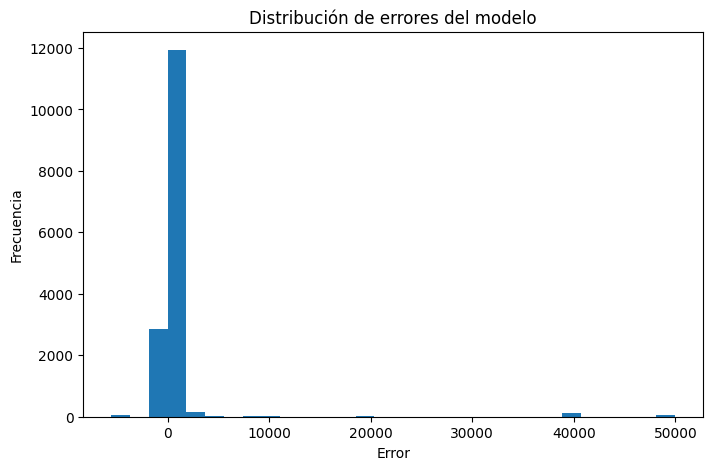

In [15]:
errores = y_test.values - y_pred_test

plt.figure(figsize=(8, 5))
plt.hist(errores, bins=30)
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.title("Distribución de errores del modelo")
plt.show()

In [ ]:
# Sobreajuste

# Predicciones en entrenamiento
y_train_pred = nb_reg.predict(X_train_scaled)

# Predicciones en prueba
y_test_pred = nb_reg.predict(X_test_scaled)

# Accuracy
train_acc = accuracy_score(y_train_bins, y_train_pred)
test_acc = accuracy_score(y_test_bins, y_test_pred)

print("Accuracy entrenamiento:", train_acc)
print("Accuracy prueba:", test_acc)

# Reporte (opcional)
print("\n--- Entrenamiento ---")
print(classification_report(y_train_bins, y_train_pred))

print("\n--- Prueba ---")
print(classification_report(y_test_bins, y_test_pred))

NameError: name 'model' is not defined